# Step 7 — Trend Projection to 2030
Polynomial projection of global data centre energy consumption with efficiency scenario.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

df = pd.read_csv('../data/ai_datacenter_enriched.csv')
global_energy = df[df['company'] == 'All'][['year', 'electricity_gwh']].dropna().sort_values('year')
print(f"Global energy data points: {len(global_energy)}")
global_energy

Global energy data points: 10


,year,electricity_gwh
40,2015,400000.0
41,2016,415000.0
42,2017,430000.0
43,2018,450000.0
44,2019,475000.0
45,2020,500000.0
46,2021,540000.0
47,2022,600000.0
48,2023,700000.0
49,2024,850000.0


In [2]:
x = global_energy['year'].values
y = global_energy['electricity_gwh'].values

coeffs = np.polyfit(x, y, deg=2)
poly = np.poly1d(coeffs)

future_years = np.arange(2015, 2031)
projection_bau = poly(future_years)
projection_efficient = projection_bau * 0.85
projection_aggressive = projection_bau * 0.70

print(f"Polynomial coefficients: {coeffs}")
print(f"\nProjected 2030 BAU: {projection_bau[-1]:,.0f} GWh ({projection_bau[-1]/1000:,.0f} TWh)")
print(f"Projected 2030 Efficiency: {projection_efficient[-1]:,.0f} GWh")
print(f"Projected 2030 Aggressive: {projection_aggressive[-1]:,.0f} GWh")

Polynomial coefficients: [ 6.93181818e+03 -2.79540379e+07  2.81830679e+10]

Projected 2030 BAU: 1,700,591 GWh (1,701 TWh)
Projected 2030 Efficiency: 1,445,502 GWh
Projected 2030 Aggressive: 1,190,414 GWh


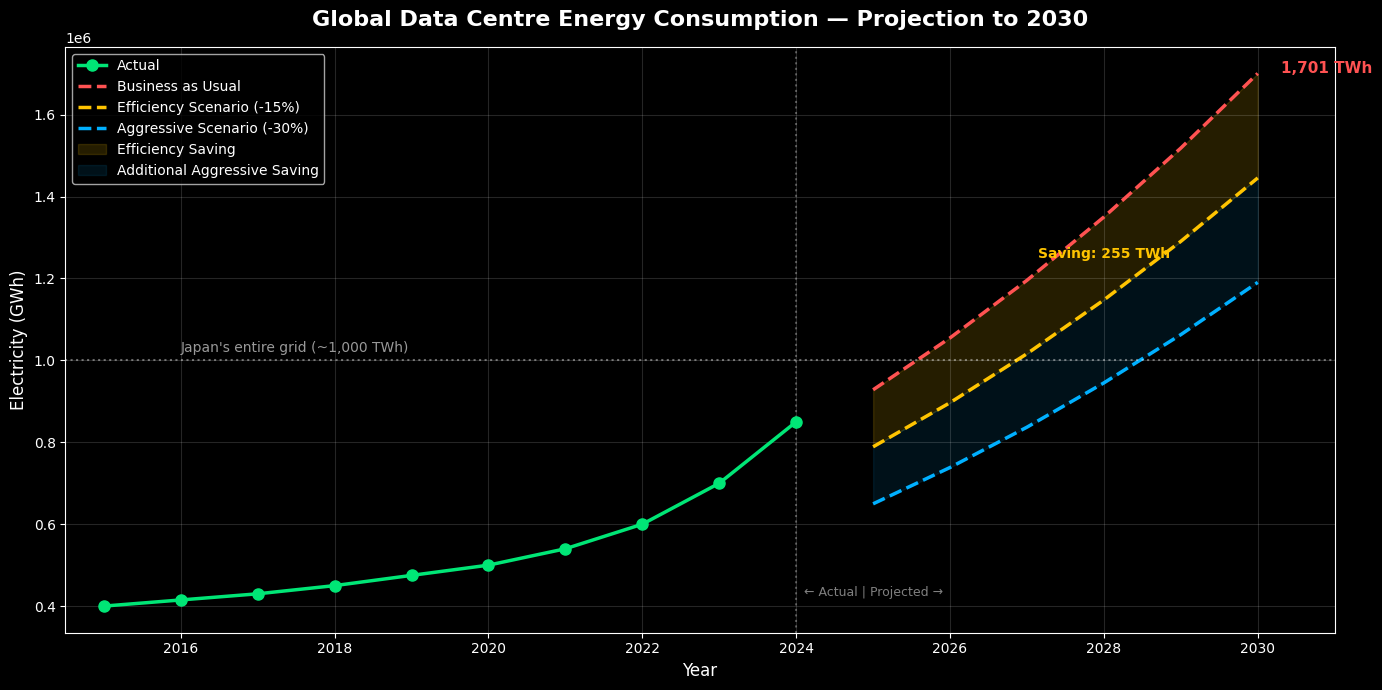

In [3]:
fig, ax = plt.subplots(figsize=(14, 7))

# Actual data
ax.plot(x, y, 'o-', color='#00e676', label='Actual', linewidth=2.5, markersize=8, zorder=5)

# Projections (future only)
future_mask = future_years > x.max()
ax.plot(future_years[future_mask], projection_bau[future_mask],
        '--', color='#ff5252', label='Business as Usual', linewidth=2.5)
ax.plot(future_years[future_mask], projection_efficient[future_mask],
        '--', color='#ffc400', label='Efficiency Scenario (-15%)', linewidth=2.5)
ax.plot(future_years[future_mask], projection_aggressive[future_mask],
        '--', color='#00b0ff', label='Aggressive Scenario (-30%)', linewidth=2.5)

# Fill savings zones
ax.fill_between(future_years[future_mask],
                projection_efficient[future_mask],
                projection_bau[future_mask],
                alpha=0.15, color='#ffc400', label='Efficiency Saving')
ax.fill_between(future_years[future_mask],
                projection_aggressive[future_mask],
                projection_efficient[future_mask],
                alpha=0.1, color='#00b0ff', label='Additional Aggressive Saving')

# Reference lines
ax.axhline(y=1000000, color='white', linestyle=':', alpha=0.4)
ax.text(2016, 1020000, 'Japan\'s entire grid (~1,000 TWh)', color='white', alpha=0.6, fontsize=10)

ax.axvline(x=2024, color='white', linestyle=':', alpha=0.3)
ax.text(2024.1, max(y)*0.5, '← Actual | Projected →', color='white', alpha=0.5, fontsize=9)

# Annotations
ax.annotate(f'{projection_bau[-1]/1000:,.0f} TWh',
            xy=(2030, projection_bau[-1]),
            xytext=(2030.3, projection_bau[-1]),
            fontsize=11, fontweight='bold', color='#ff5252')

saving = (projection_bau[-1] - projection_efficient[-1]) / 1000
ax.annotate(f'Saving: {saving:,.0f} TWh',
            xy=(2028, (projection_bau[future_years == 2028][0] + projection_efficient[future_years == 2028][0]) / 2),
            fontsize=10, color='#ffc400', fontweight='bold',
            ha='center')

ax.set_title('Global Data Centre Energy Consumption — Projection to 2030',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Electricity (GWh)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.15)
ax.set_xlim(2014.5, 2031)

plt.tight_layout()
plt.savefig('../outputs/energy_projection_2030.png', dpi=150, bbox_inches='tight')
plt.show()

## Water Consumption Projection

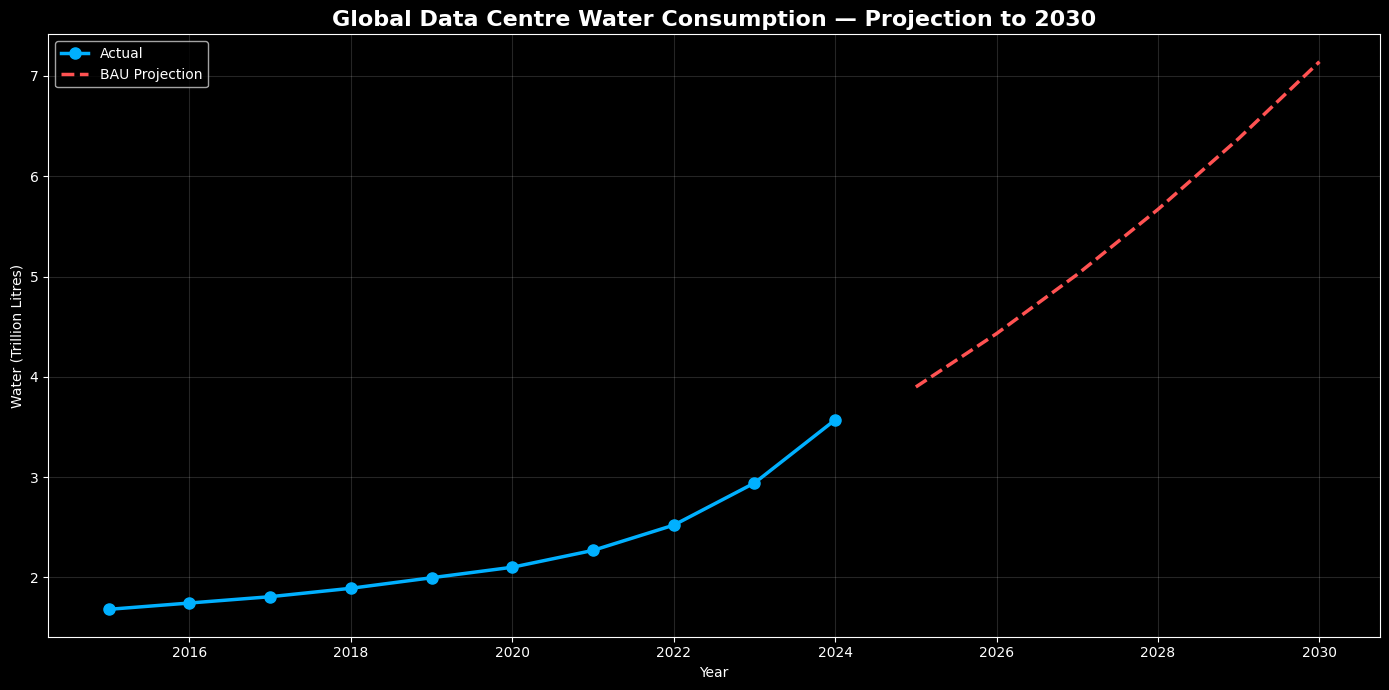

In [4]:
global_water = df[df['company'] == 'All'][['year', 'water_litres']].dropna().sort_values('year')
xw = global_water['year'].values
yw = global_water['water_litres'].values

coeffs_w = np.polyfit(xw, yw, deg=2)
poly_w = np.poly1d(coeffs_w)
water_bau = poly_w(future_years)

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(xw, yw / 1e12, 'o-', color='#00b0ff', label='Actual', linewidth=2.5, markersize=8)
ax.plot(future_years[future_mask], water_bau[future_mask] / 1e12,
        '--', color='#ff5252', label='BAU Projection', linewidth=2.5)

ax.set_title('Global Data Centre Water Consumption — Projection to 2030',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Water (Trillion Litres)')
ax.legend()
ax.grid(alpha=0.15)

plt.tight_layout()
plt.savefig('../outputs/water_projection_2030.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Table

In [5]:
summary = pd.DataFrame({
    'Scenario': ['Business as Usual', 'Efficiency (-15%)', 'Aggressive (-30%)'],
    '2026 Energy (TWh)': [
        round(poly(2026)/1000),
        round(poly(2026)*0.85/1000),
        round(poly(2026)*0.70/1000)
    ],
    '2030 Energy (TWh)': [
        round(poly(2030)/1000),
        round(poly(2030)*0.85/1000),
        round(poly(2030)*0.70/1000)
    ],
    '2030 Water (T Litres)': [
        round(poly_w(2030)/1e12, 1),
        round(poly_w(2030)*0.85/1e12, 1),
        round(poly_w(2030)*0.70/1e12, 1)
    ]
})
summary

,Scenario,2026 Energy (TWh),2030 Energy (TWh),2030 Water (T Litres)
0,Business as Usual,1055,1701,7.1
1,Efficiency (-15%),897,1446,6.1
2,Aggressive (-30%),738,1190,5.0
